In [160]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt

In [161]:
file_path = os.path.join('data', 'student_performance.csv')
df = pd.read_csv(file_path)
df = df.copy()
df.head(100)


,student_id,department,semester,course_load,study_hours_weekly,gpa,attendance_pct,has_internship,commute_minutes,scholarship
0,STU00001,Biology,Fall 2023,5,18.0,3.36,57.8,No,24.0,Department
1,STU00002,Mathematics,Fall 2023,5,9.2,2.21,96.5,No,34.0,Athletic
2,STU00003,Business,Fall 2024,4,26.4,2.69,61.3,No,32.0,Need-based
3,STU00004,Engineering,Fall 2023,5,19.5,2.78,83.4,Yes,49.0,NaN
4,STU00005,Engineering,Fall 2024,5,15.7,2.42,62.1,No,27.0,Athletic
...,...,...,...,...,...,...,...,...,...,...
95,STU00096,Engineering,Spring 2024,4,12.6,2.09,89.4,No,NaN,Department
96,STU00097,Computer Science,Fall 2023,3,12.3,2.88,61.0,Yes,41.0,NaN
97,STU00098,Business,Fall 2024,3,12.0,2.24,74.4,Yes,15.0,NaN
98,STU00099,Business,Spring 2024,3,5.3,2.24,59.8,Yes,NaN,Need-based


In [162]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          2000 non-null   str    
 1   department          2000 non-null   str    
 2   semester            2000 non-null   str    
 3   course_load         2000 non-null   int64  
 4   study_hours_weekly  2000 non-null   float64
 5   gpa                 2000 non-null   float64
 6   attendance_pct      2000 non-null   float64
 7   has_internship      2000 non-null   str    
 8   commute_minutes     1819 non-null   float64
 9   scholarship         1611 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 156.4 KB
None


In [163]:
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 2000 rows and 10 columns.


In [164]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / 2000) * 100
missing_data = pd.DataFrame({'Missing Count': missing_counts, 'Missing Percentage': missing_pct})
print(missing_data)


                    Missing Count  Missing Percentage
student_id                      0                0.00
department                      0                0.00
semester                        0                0.00
course_load                     0                0.00
study_hours_weekly              0                0.00
gpa                             0                0.00
attendance_pct                  0                0.00
has_internship                  0                0.00
commute_minutes               181                9.05
scholarship                   389               19.45


In [165]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          2000 non-null   str    
 1   department          2000 non-null   str    
 2   semester            2000 non-null   str    
 3   course_load         2000 non-null   int64  
 4   study_hours_weekly  2000 non-null   float64
 5   gpa                 2000 non-null   float64
 6   attendance_pct      2000 non-null   float64
 7   has_internship      2000 non-null   str    
 8   commute_minutes     1819 non-null   float64
 9   scholarship         1611 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 156.4 KB
None


In [166]:
print(df.describe())

       course_load  study_hours_weekly          gpa  attendance_pct  \
count  2000.000000          2000.00000  2000.000000     2000.000000   
mean      4.470500            14.88105     2.774545       77.479650   
std       1.110741             5.88398     0.427506       11.773926   
min       3.000000             1.00000     1.310000       36.700000   
25%       3.000000            10.90000     2.480000       69.900000   
50%       4.000000            14.90000     2.785000       77.300000   
75%       5.000000            19.00000     3.080000       86.000000   
max       6.000000            33.00000     4.000000      100.000000   

       commute_minutes  
count      1819.000000  
mean         25.547554  
std          11.565584  
min           5.000000  
25%          17.000000  
50%          25.000000  
75%          33.000000  
max          79.000000  


In [167]:
os.makedirs('output', exist_ok=True)

In [168]:
with open('output/data_profile.txt', 'w', encoding='utf-8') as f:
        f.write("=== Data Profile Report ===\n\n")
        f.write(f"1. Shape:\n- Rows: {rows}\n- Columns: {cols}\n\n")
        
        f.write("2. Data Types:\n")
        f.write(df.dtypes.to_string() + "\n\n")
        
        f.write("3. Missing Values (Count and Percentage):\n")
        for col in df.columns:
            f.write(f"- {col}: {missing_counts[col]} missing ({missing_pct[col]:.2f}%)\n")
            
        f.write("\n4. Handling Decisions and Reasoning:\n")
        f.write("- commute_minutes: Impute with median. \n")
        f.write("  Reasoning: It has ~10% missing values. Dropping 10% of the data might lead to loss of valuable information. We use the median instead of the mean because commute times can have outliers (e.g., extremely long commutes), and the median is robust to outliers.\n\n")
        
        f.write("- study_hours_weekly: Drop missing rows. \n")
        f.write("  Reasoning: It has ~5% missing values (which is a small percentage). Since it is roughly Missing Completely At Random (MCAR), dropping these few rows will not significantly affect the dataset's statistical power.\n")

In [169]:
commute_median = df['commute_minutes'].median()
df['commute_minutes'] = df['commute_minutes'].fillna(commute_median)

print(f"Filled commute_minutes with median: {commute_median}")

Filled commute_minutes with median: 25.0


In [170]:
df['scholarship'] = df['scholarship'].fillna('None')

print("Filled scholarship NaNs with 'None'")

Filled scholarship NaNs with 'None'


In [171]:
df = df.dropna(subset=['study_hours_weekly'])

In [172]:
df.dropna(subset=['study_hours_weekly'], inplace=True)

In [173]:
print(df.head())

  student_id   department   semester  course_load  study_hours_weekly   gpa  \
0   STU00001      Biology  Fall 2023            5                18.0  3.36   
1   STU00002  Mathematics  Fall 2023            5                 9.2  2.21   
2   STU00003     Business  Fall 2024            4                26.4  2.69   
3   STU00004  Engineering  Fall 2023            5                19.5  2.78   
4   STU00005  Engineering  Fall 2024            5                15.7  2.42   

   attendance_pct has_internship  commute_minutes scholarship  
0            57.8             No             24.0  Department  
1            96.5             No             34.0    Athletic  
2            61.3             No             32.0  Need-based  
3            83.4            Yes             49.0        None  
4            62.1             No             27.0    Athletic  


In [175]:
sns.set_theme(style="whitegrid")

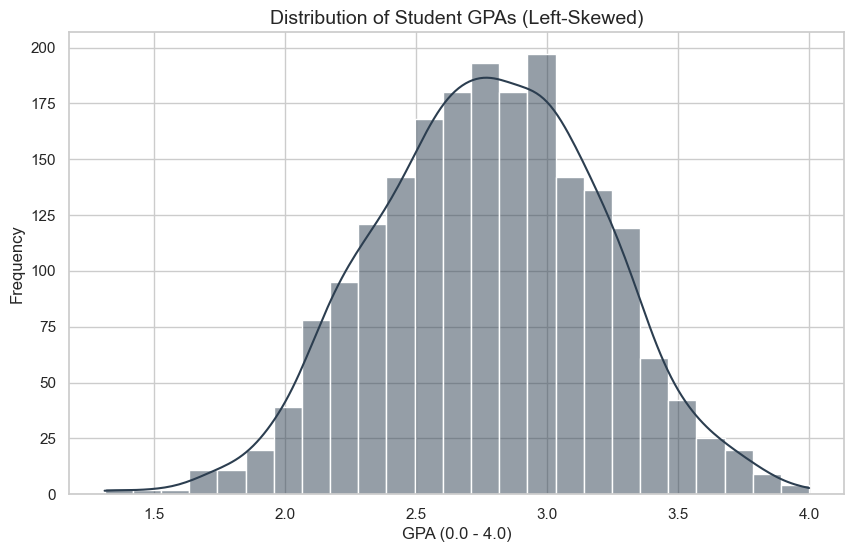

In [ ]:
def plot_gpa_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['gpa'].dropna(), kde=True, color='#2c3e50', bins=25)
    
    plt.title('Distribution of Student GPAs (Left-Skewed)', fontsize=14)
    plt.xlabel('GPA (0.0 - 4.0)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()

plot_gpa_distribution(df)

In [177]:
plt.savefig('output/gpa_distribution.png', bbox_inches='tight')
plt.close()

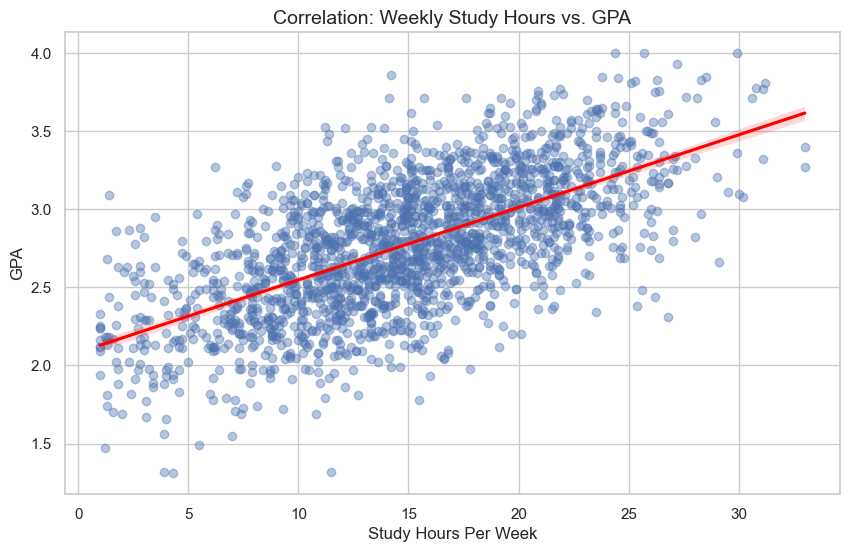

In [ ]:
def plot_study_vs_gpa(df):
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x='study_hours_weekly', y='gpa', 
                scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    
    plt.title('Correlation: Weekly Study Hours vs. GPA', fontsize=14)
    plt.xlabel('Study Hours Per Week', fontsize=12)
    plt.ylabel('GPA', fontsize=12)
    plt.show()

plot_study_vs_gpa(df)


In [179]:
plt.savefig('output/study_hours_vs_gpa.png', bbox_inches='tight')
plt.close()

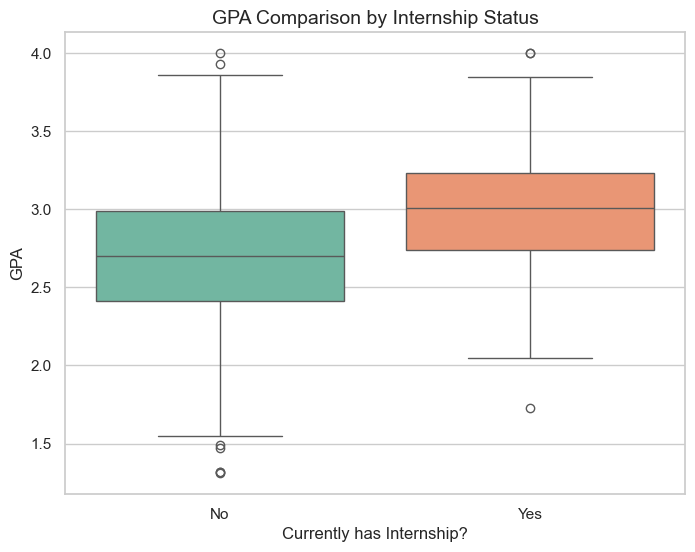

In [ ]:
def plot_internship_comparison(df):
    plt.figure(figsize=(8, 6))
    
    sns.boxplot(
        data=df, 
        x='has_internship', 
        y='gpa', 
        hue='has_internship', 
        palette='Set2', 
        legend=False
    )
    
    plt.title('GPA Comparison by Internship Status', fontsize=14)
    plt.xlabel('Currently has Internship?', fontsize=12)
    plt.ylabel('GPA', fontsize=12)
    plt.show()

plot_internship_comparison(df)

In [181]:
plt.savefig('output/internship_vs_gpa.png', bbox_inches='tight')
plt.close()

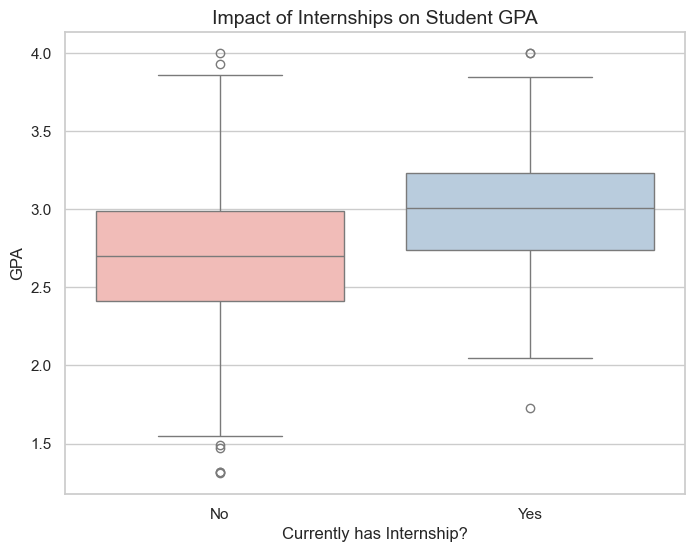

In [ ]:
def plot_internship_impact(df):
    plt.figure(figsize=(8, 6))
    
    sns.boxplot(
        data=df, 
        x='has_internship', 
        y='gpa', 
        hue='has_internship', 
        palette='Pastel1', 
        legend=False
    )
    
    plt.title('Impact of Internships on Student GPA', fontsize=14)
    plt.xlabel('Currently has Internship?', fontsize=12)
    plt.ylabel('GPA', fontsize=12)
    plt.show()

plot_internship_impact(df)

In [184]:
plt.savefig('output/internship_gpa.png', bbox_inches='tight')
plt.close()

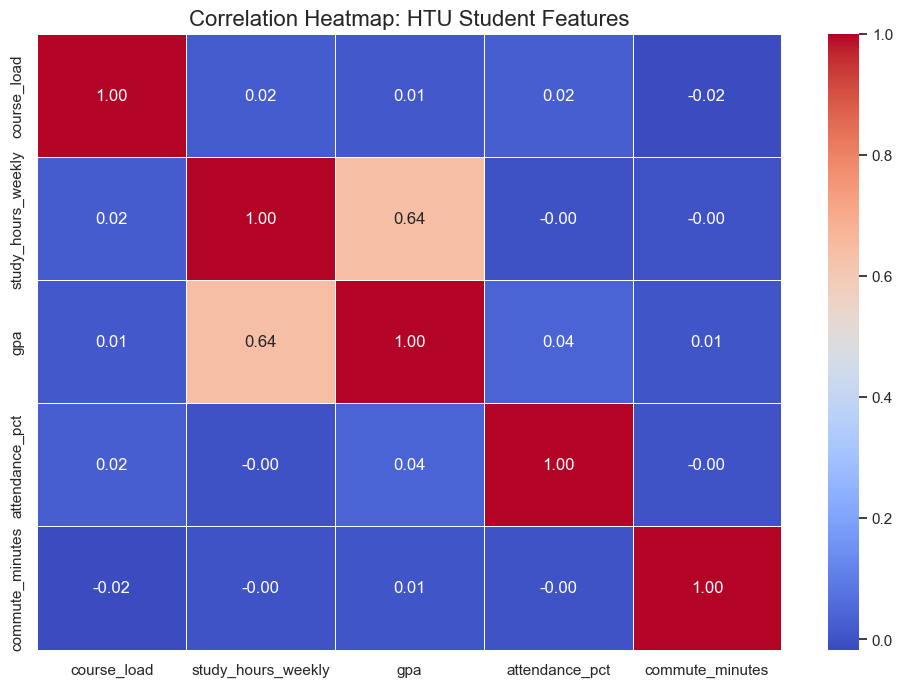

In [ ]:
def plot_correlation_heatmap(df):
    plt.figure(figsize=(12, 8))
    
    numeric_df = df.select_dtypes(include=['float64', 'int64'])
    corr_matrix = numeric_df.corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    
    plt.title('Correlation Heatmap: HTU Student Features', fontsize=16)
    plt.show()

plot_correlation_heatmap(df)

In [186]:
plt.savefig('output/correlation_heatmap.png', bbox_inches='tight')
plt.close()

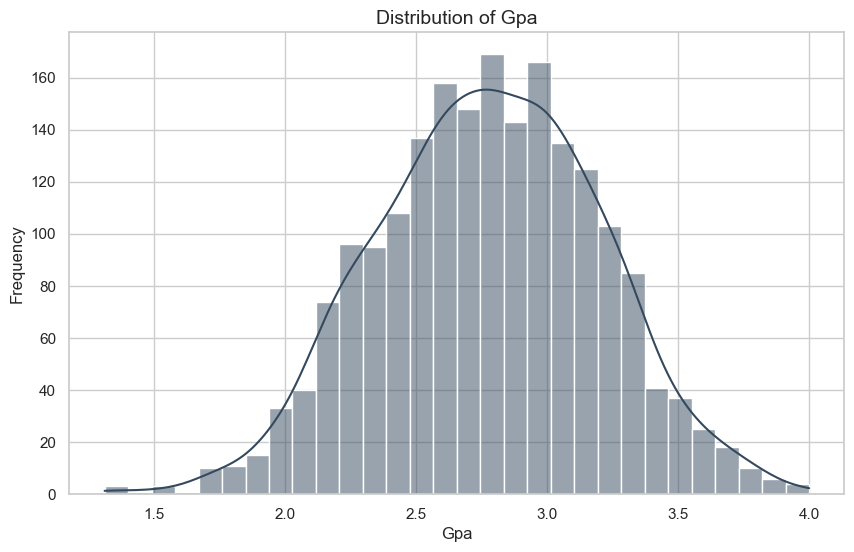

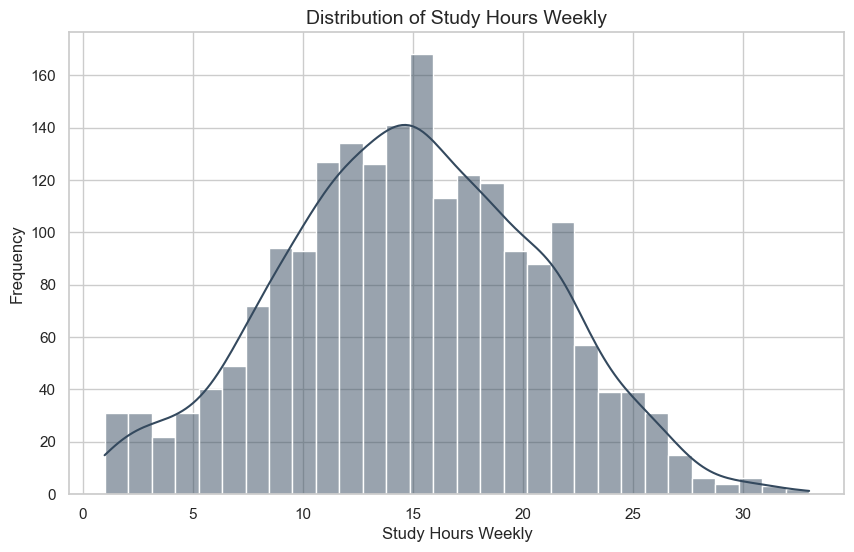

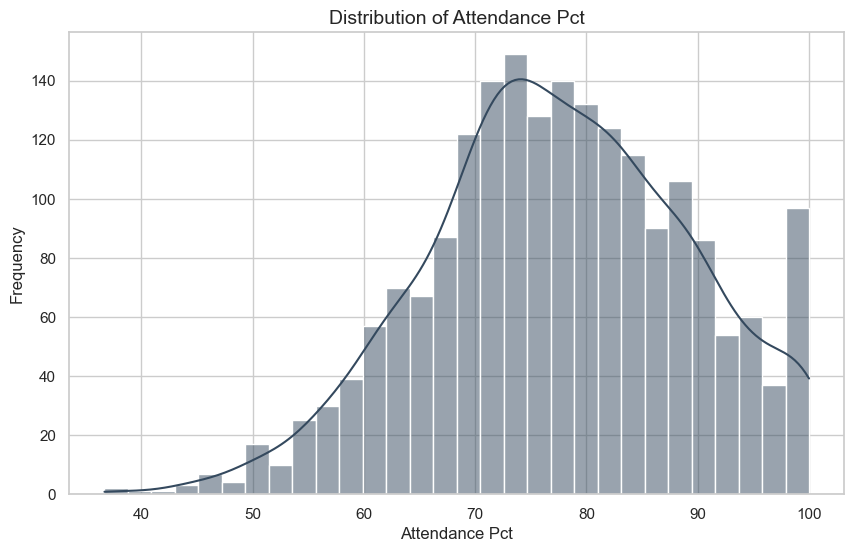

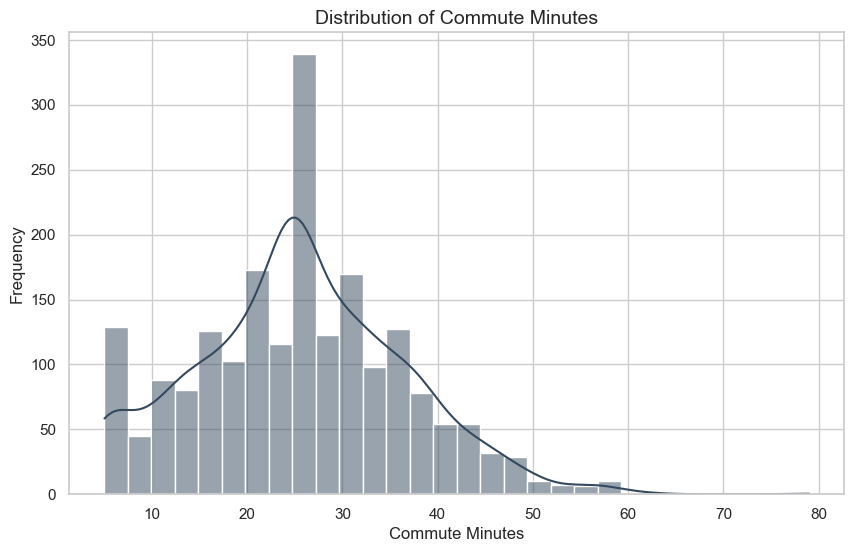

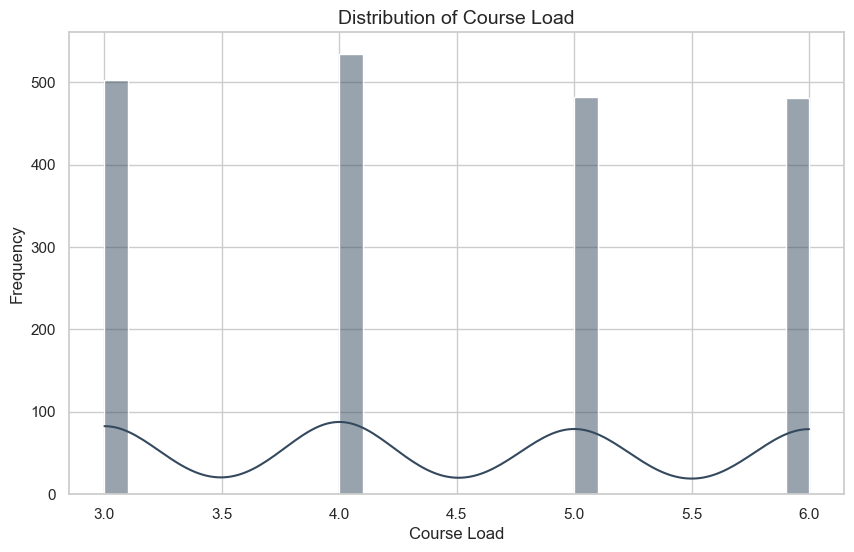

In [187]:
def plot_numeric_distributions(df):
    numeric_cols = ['gpa', 'study_hours_weekly', 'attendance_pct', 'commute_minutes' ,"course_load"]
    
    for col in numeric_cols:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col].dropna(), kde=True, color='#34495e', bins=30)
        
        plt.title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14)
        plt.xlabel(col.replace("_", " ").title(), fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.show()
        
plot_numeric_distributions(df)

In [188]:
plt.savefig('output/numeric_distributions.png', bbox_inches='tight')
plt.close()

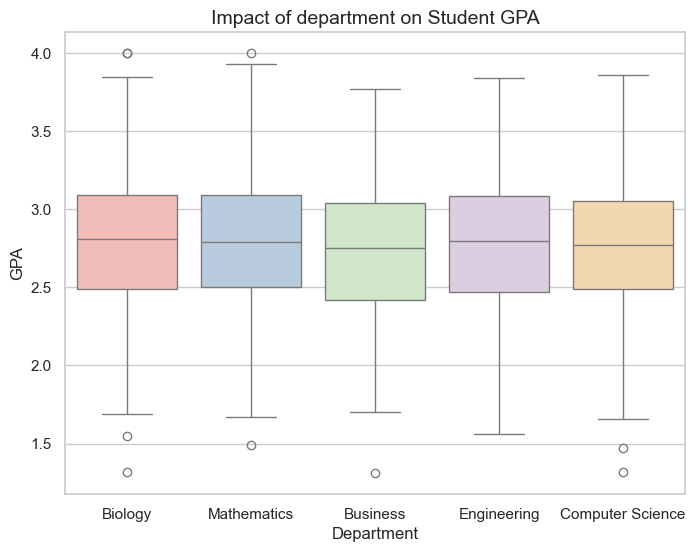

In [ ]:
def plot_department_vs_gap(df):
    plt.figure(figsize=(8, 6))
    
    sns.boxplot(
        data=df, 
        x='department', 
        y='gpa', 
        hue='department', 
        palette='Pastel1', 
        legend=False
    )
    
    plt.title('Impact of department on Student GPA', fontsize=14)
    plt.xlabel('Department', fontsize=12)
    plt.ylabel('GPA', fontsize=12)
    plt.show()

plot_department_vs_gap(df)

In [190]:
plt.savefig('output/department_vs_gpa.png', bbox_inches='tight')
plt.close()

In [193]:
plt.close()

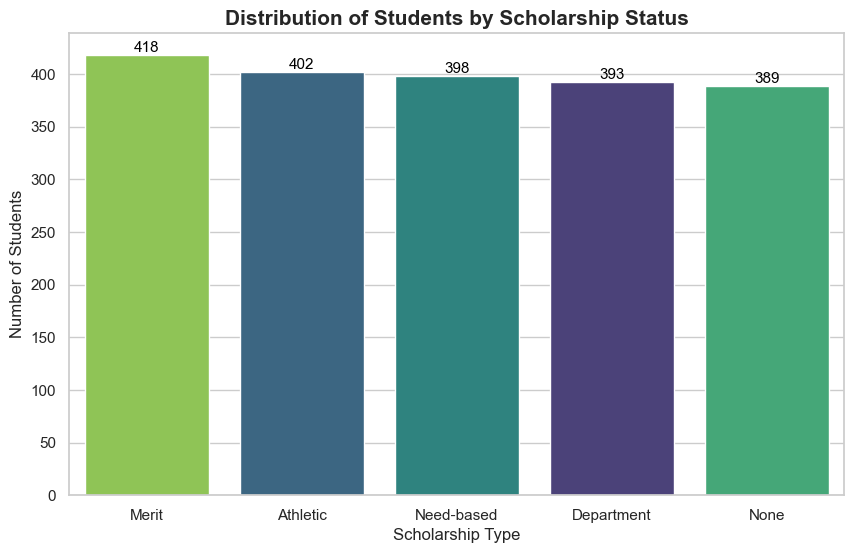

In [ ]:
def plot_scholarship_distribution(df):
    plt.figure(figsize=(10, 6))
    
    sns.countplot(
        data=df, 
        x='scholarship', 
        hue='scholarship', 
        palette='viridis', 
        order=df['scholarship'].value_counts().index,
        legend=False        
    )
    
    plt.title('Distribution of Students by Scholarship Status', fontsize=15, fontweight='bold')
    plt.xlabel('Scholarship Type', fontsize=12)
    plt.ylabel('Number of Students', fontsize=12)
    

    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', fontsize=11, 
                        color='black', xytext=(0, 5),
                        textcoords='offset points')

    plt.savefig('output/scholarship_distribution.png', dpi=300)
    plt.show()

plot_scholarship_distribution(df)

In [192]:
plt.savefig('output/distribution_scholarship.png', bbox_inches='tight')
plt.close()

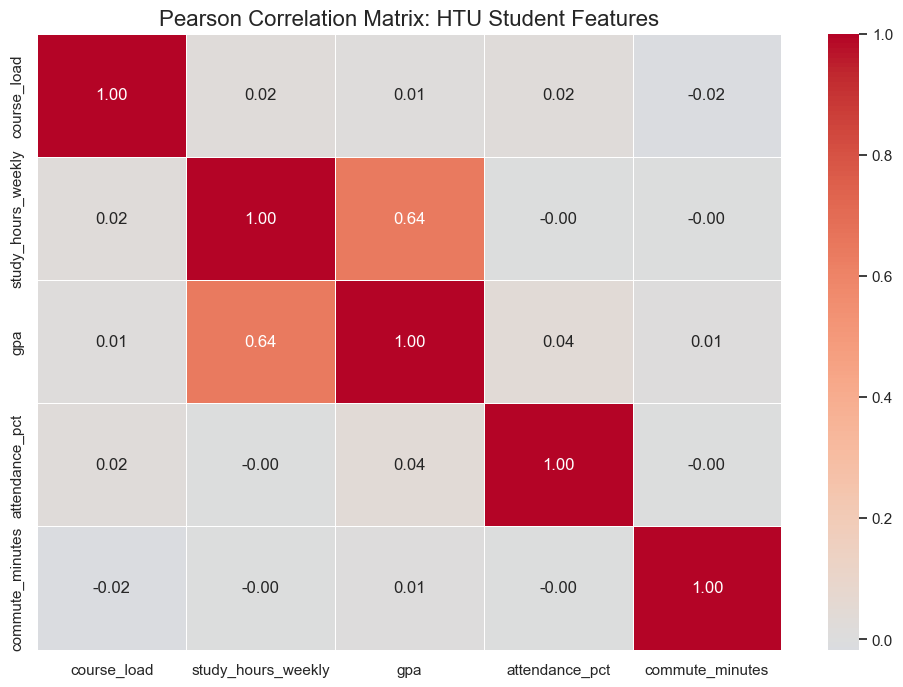

In [194]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['student_id'], errors='ignore')
corr_matrix = numeric_cols.corr(method='pearson')
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Pearson Correlation Matrix: HTU Student Features', fontsize=16)
plt.savefig('output/pearson_correlation.png', bbox_inches='tight')
plt.show()
plt.close()

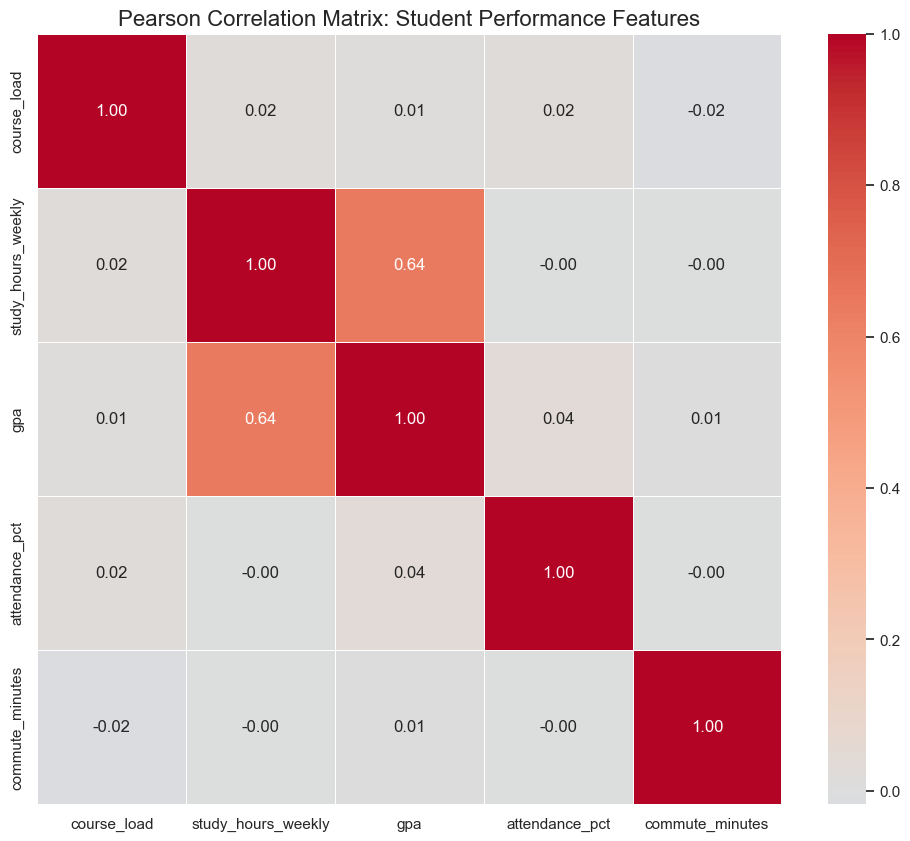


--- Top 2 Correlated Pairs ---
study_hours_weekly  gpa               0.639382
gpa                 attendance_pct    0.040761
dtype: float64


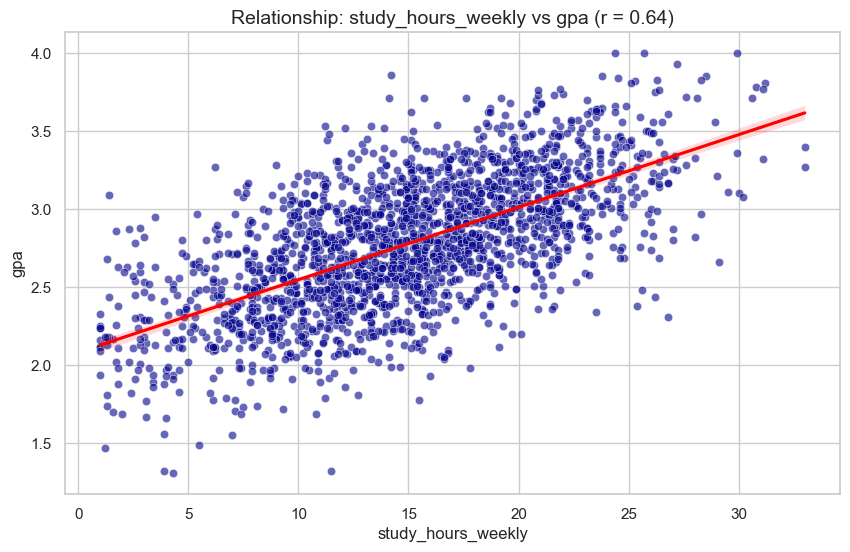

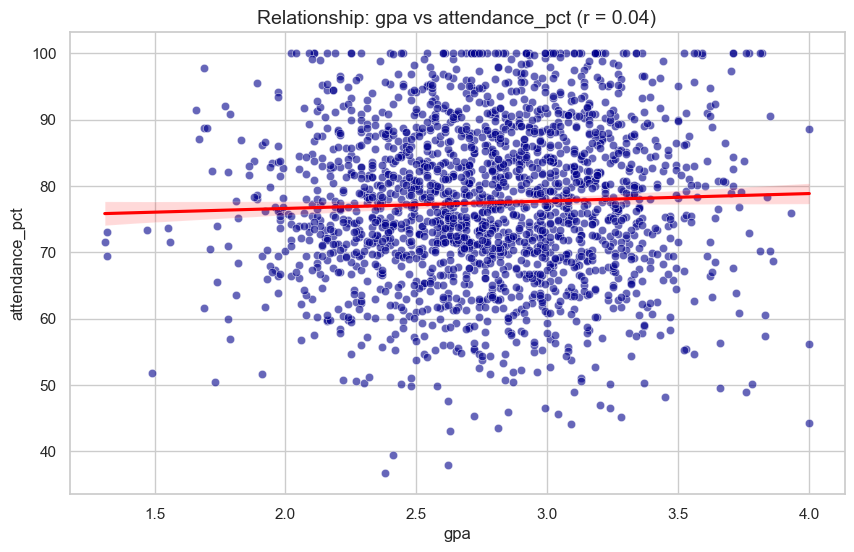

In [ ]:
def perform_correlation_analysis(df):
    
    # --- 1. Compute Pearson Correlation Matrix ---
    numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['student_id'], errors='ignore')
    corr_matrix = numeric_cols.corr(method='pearson')
    
    # --- 2. Visualize as Annotated Heatmap ---
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Pearson Correlation Matrix: Student Performance Features', fontsize=16)
    plt.savefig('output/correlation_heatmap.png', dpi=300)
    plt.show()

    # --- 3. Identify Top 2 Correlated Pairs (Excluding self-correlation) ---
    sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))
    
    top_pairs = sol.head(2)
    print("\n--- Top 2 Correlated Pairs ---")
    print(top_pairs)

    # --- 4. Create Scatter Plots for Top Pairs ---
    for i, ((var1, var2), val) in enumerate(top_pairs.items()):
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=var1, y=var2, alpha=0.6, color='darkblue')
        sns.regplot(data=df, x=var1, y=var2, scatter=False, color='red') 
        
        plt.title(f'Relationship: {var1} vs {var2} (r = {val:.2f})', fontsize=14)
        plt.savefig(f'output/top_correlation_{i+1}.png', dpi=300)
        plt.show()

    return top_pairs

top_results = perform_correlation_analysis(df)

In [ ]:
def perform_hypothesis_testing(df):
    print("--- Task 4: Hypothesis Testing Results ---\n")

    # --- Hypothesis 1: Internship vs GPA (T-Test) ---
    gpa_intern = df[df['has_internship'] == 'Yes']['gpa'].dropna()
    gpa_no_intern = df[df['has_internship'] == 'No']['gpa'].dropna()

    # T-test 
    t_stat, p_val_t = stats.ttest_ind(gpa_intern, gpa_no_intern)

    # Cohen's d 
    n1, n2 = len(gpa_intern), len(gpa_no_intern)
    s1, s2 = np.var(gpa_intern, ddof=1), np.var(gpa_no_intern, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    cohen_d = (np.mean(gpa_intern) - np.mean(gpa_no_intern)) / pooled_std

    print("Hypothesis 1: Students with internships have a higher GPA.")
    print(f"t-statistic: {t_stat:.4f}, p-value: {p_val_t:.4e}")
    print(f"Cohen's d: {cohen_d:.4f}")
    
    
    if p_val_t < 0.05:
        print("Interpretation: Significant difference found! Internships are linked to higher GPAs.")
    else:
        print("Interpretation: No significant difference. GPA does not seem to depend on internship status.")
    print("-" * 50)

    # --- Hypothesis 2: Scholarship vs Department (Chi-Square) ---
    #(Contingency Table)
    contingency_table = pd.crosstab(df['scholarship'], df['department'])
    
    # Chi-square
    chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

    print("Hypothesis 2: Scholarship status is associated with department.")
    print(f"Chi-square statistic: {chi2:.4f}, p-value: {p_val_chi:.4e}")
    print(f"Degrees of Freedom: {dof}")

    if p_val_chi < 0.05:
        print("Interpretation: There is a significant association between scholarships and departments.")
    else:
        print("Interpretation: No significant association. Scholarships are distributed independently of departments.")

perform_hypothesis_testing(df)

--- Task 4: Hypothesis Testing Results ---

Hypothesis 1: Students with internships have a higher GPA.
t-statistic: 13.5644, p-value: 3.6848e-40
Cohen's d: 0.6898
Interpretation: Significant difference found! Internships are linked to higher GPAs.
--------------------------------------------------
Hypothesis 2: Scholarship status is associated with department.
Chi-square statistic: 17.1358, p-value: 3.7686e-01
Degrees of Freedom: 16
Interpretation: No significant association. Scholarships are distributed independently of departments.
